In [2]:
import pandas as pd

df = pd.read_csv("data/processed/M1_clean_reviews.csv")
df.shape


(103, 11)

In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|[^a-z\s]", "", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["Translated_Review"].apply(clean_text)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=100,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf.fit_transform(df["clean_text"])
keywords = pd.DataFrame({
    "keyword": tfidf.get_feature_names_out(),
    "score": tfidf_matrix.sum(axis=0).A1
}).sort_values("score", ascending=False)

keywords.head(15)


,keyword,score
31,good,11.321172
34,great,6.263349
43,helpful,6.125664
70,nice,4.560940
78,really,4.401876
57,like,4.370059
52,informative,3.868766
96,useful,3.244944
3,app,2.902819
15,easy,2.889758


In [5]:
feature_dict = {
    "Workout_Tracking": ["workout","exercise","training","routine","set","rep"],
    "UI_UX": ["ui","interface","design","easy","simple","layout"],
    "Performance_Bugs": ["bug","crash","slow","freeze","error","lag"],
    "Subscription_Pricing": ["price","subscription","paid","expensive","free"],
    "Sync_Integration": ["sync","connect","integration","fitbit","watch"],
    "Offline_Mode": ["offline","internet","connection"],
    "Customer_Support": ["support","help","service","response"]
}


In [7]:
def tag_features(text):
    tags = []
    for feature, words in feature_dict.items():
        if any(w in text for w in words):
            tags.append(feature)
    return tags

df["features"] = df["clean_text"].apply(tag_features)
feature_df = df.explode("features").dropna(subset=["features"])
feature_counts = feature_df["features"].value_counts().reset_index()
feature_counts.columns = ["Feature", "Mentions"]
feature_counts



,Feature,Mentions
0,Customer_Support,18
1,UI_UX,16
2,Performance_Bugs,3
3,Subscription_Pricing,3
4,Workout_Tracking,2


In [8]:
feature_sentiment = (
    feature_df
    .groupby("features")["compound"]
    .mean()
    .reset_index()
    .sort_values("compound")
)

feature_sentiment


,features,compound
1,Performance_Bugs,-0.028133
2,Subscription_Pricing,0.464367
3,UI_UX,0.525450
0,Customer_Support,0.575422
4,Workout_Tracking,0.662600


In [9]:
merged_feature = feature_counts.merge(
    feature_sentiment,
    left_on="Feature",
    right_on="features"
)

merged_feature.sort_values(["Mentions","compound"], ascending=[False,True])


,Feature,Mentions,features,compound
0,Customer_Support,18,Customer_Support,0.575422
1,UI_UX,16,UI_UX,0.525450
2,Performance_Bugs,3,Performance_Bugs,-0.028133
3,Subscription_Pricing,3,Subscription_Pricing,0.464367
4,Workout_Tracking,2,Workout_Tracking,0.662600


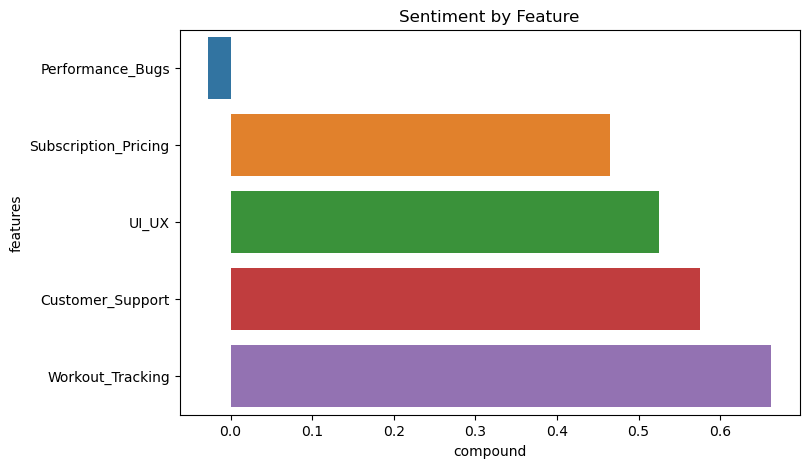

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    x="compound",
    y="features",
    data=feature_sentiment
)
plt.title("Sentiment by Feature")
plt.show()


In [16]:
merged_feature.to_csv(
    "data/processed/M2_feature_sentiment.csv",
    index=False
)
